In [8]:
!pip install kneed

In [9]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

plt.style.use('seaborn-v0_8')

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/malaikaaltaf48/customer-segmentation-kmeans-pca/refs/heads/main/Mall_Customers.csv')

# Quick look
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Inco

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


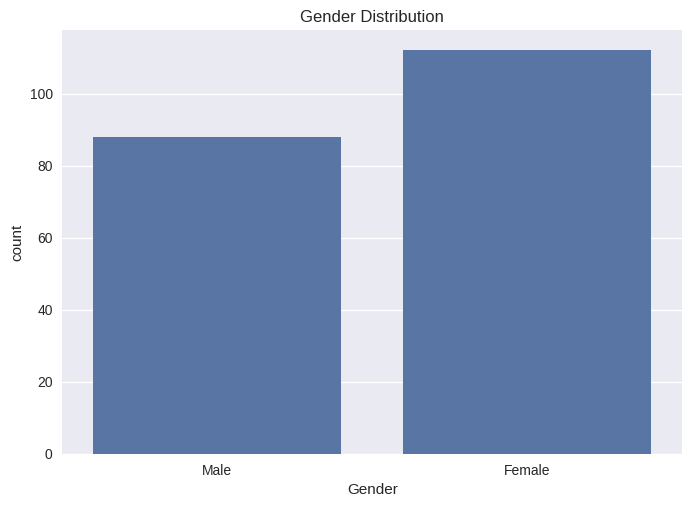

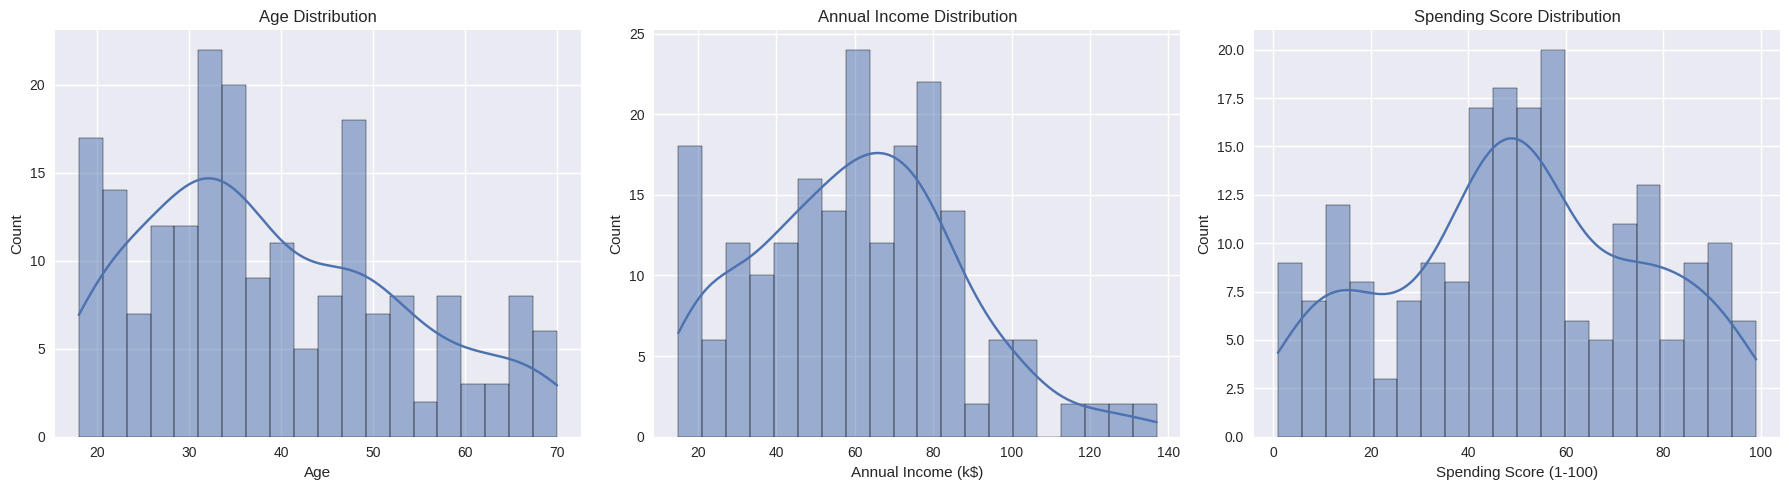

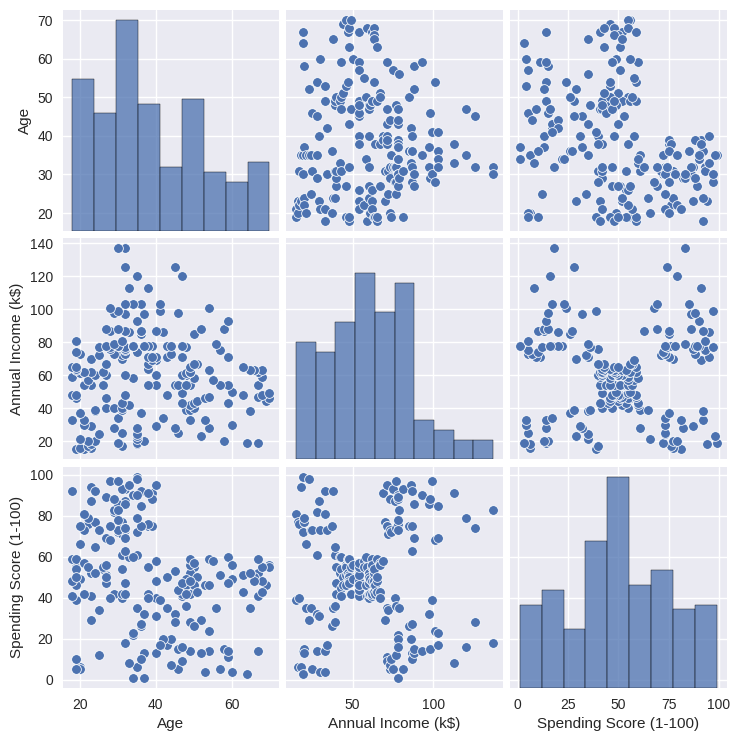

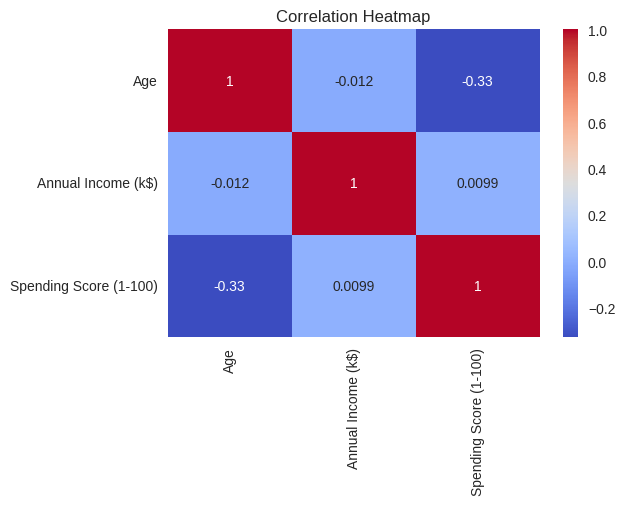

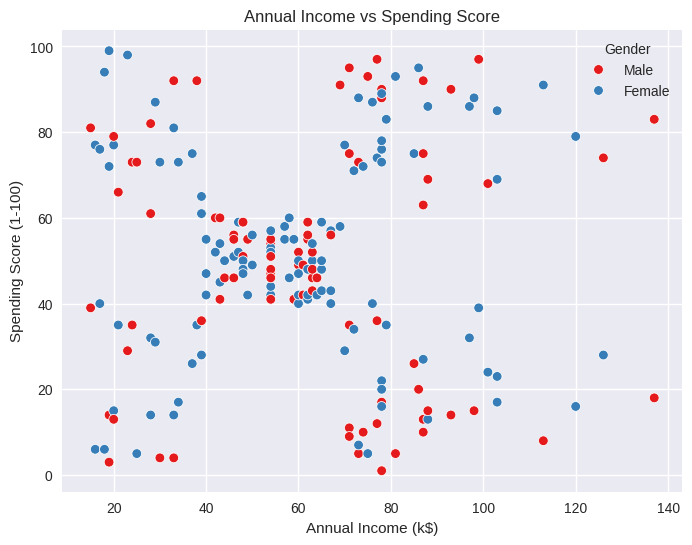

In [10]:
# Step 2: Exploratory Data Analysis (EDA)

# 2.1 - Missing values check
print("Missing Values:\n", df.isnull().sum())

# 2.2 - Gender distribution
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

# 2.3 - Distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2])
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

# 2.4 - Pairplot to see relationships between features
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.show()

# 2.5 - Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 2.6 - Income vs Spending Score (most important scatter for clustering intuition)
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                 hue='Gender', data=df, palette='Set1')
plt.title('Annual Income vs Spending Score')
plt.show()

In [11]:
# Step 3: Feature Selection + Scaling

# 3.1 - Encode Gender (categorical -> numeric)
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])  # Male=1, Female=0 (ya ulta)

# 3.2 - Select features for clustering
# Hum ye 4 features use karenge: Age, Annual Income, Spending Score, Gender
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Encoded']
X = df[features]

print("Features used for clustering:")
print(X.head())

# 3.3 - Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easy viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("\nScaled Data (mean~0, std~1):")
print(X_scaled_df.describe())

Features used for clustering:
   Age  Annual Income (k$)  Spending Score (1-100)  Gender_Encoded
0   19                  15                      39               1
1   21                  15                      81               1
2   20                  16                       6               0
3   23                  16                      77               0
4   31                  17                      40               0

Scaled Data (mean~0, std~1):
                Age  Annual Income (k$)  Spending Score (1-100)  \
count  2.000000e+02        2.000000e+02            2.000000e+02   
mean  -1.021405e-16       -2.131628e-16           -1.465494e-16   
std    1.002509e+00        1.002509e+00            1.002509e+00   
min   -1.496335e+00       -1.738999e+00           -1.910021e+00   
25%   -7.248436e-01       -7.275093e-01           -5.997931e-01   
50%   -2.045351e-01        3.587926e-02           -7.764312e-03   
75%    7.284319e-01        6.656748e-01            8.851316e-01   
ma

Explained Variance per component: [0.33690046 0.26230645 0.23260639 0.16818671]
Cumulative Variance: [0.33690046 0.5992069  0.83181329 1.        ]


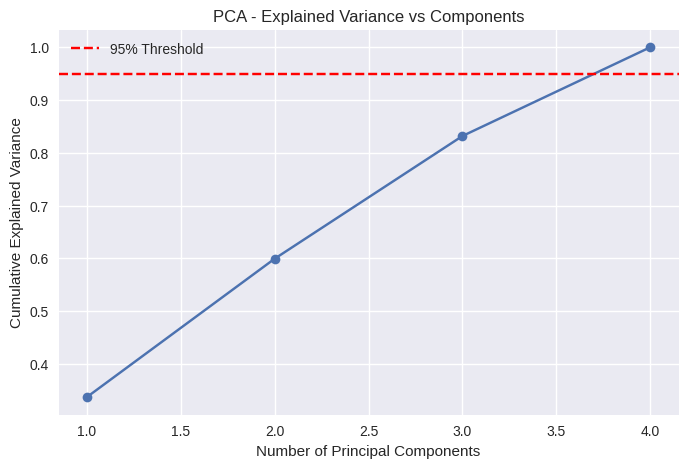


Shape after PCA: (200, 2)
Variance explained by 2 components: 0.5992069019819846


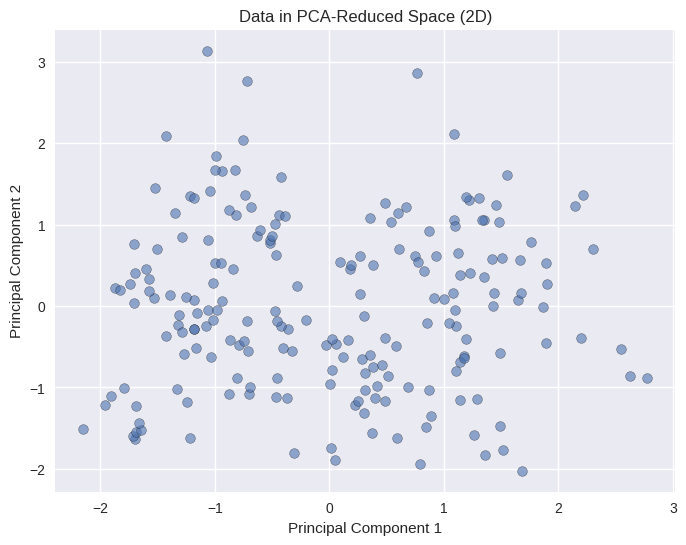

In [12]:
# Step 4: PCA (Dimensionality Reduction)

# 4.1 - First check: how much variance each component explains
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance per component:", explained_variance)
print("Cumulative Variance:", cumulative_variance)

# 4.2 - Plot cumulative explained variance (the "95% Rule" from slides)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance vs Components')
plt.legend()
plt.grid(True)
plt.show()

# 4.3 - Apply PCA with 2 components (for easy 2D visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nShape after PCA:", X_pca.shape)
print("Variance explained by 2 components:", pca.explained_variance_ratio_.sum())

# 4.4 - Visualize the PCA-reduced data
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Data in PCA-Reduced Space (2D)')
plt.grid(True)
plt.show()

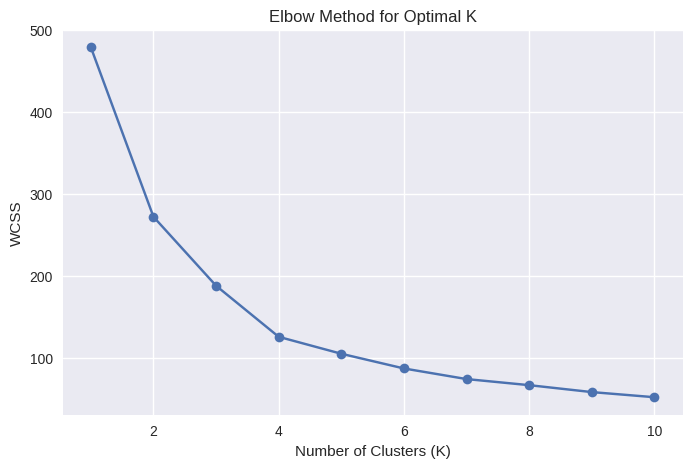

Optimal K from Elbow Method: 4
K=2, Silhouette Score=0.4014
K=3, Silhouette Score=0.3887
K=4, Silhouette Score=0.4164
K=5, Silhouette Score=0.3878
K=6, Silhouette Score=0.3940
K=7, Silhouette Score=0.3806
K=8, Silhouette Score=0.3643
K=9, Silhouette Score=0.3663
K=10, Silhouette Score=0.3835


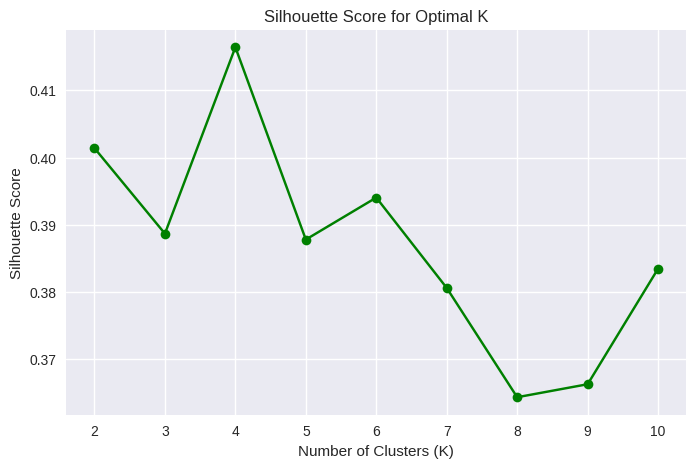


Optimal K from Silhouette Score: 4


In [13]:
# Step 5: Finding Optimal K

# 5.1 - Elbow Method (WCSS)
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot Elbow graph
plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

# 5.2 - Automatically detect the elbow point using KneeLocator
kl = KneeLocator(K_range, wcss, curve='convex', direction='decreasing')
print("Optimal K from Elbow Method:", kl.elbow)

# 5.3 - Silhouette Score for different K values
silhouette_scores = []
K_range_sil = range(2, 11)  # silhouette needs at least 2 clusters

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

# Plot Silhouette scores
plt.figure(figsize=(8,5))
plt.plot(K_range_sil, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.grid(True)
plt.show()

# 5.4 - Best K based on highest silhouette score
best_k = K_range_sil[np.argmax(silhouette_scores)]
print("\nOptimal K from Silhouette Score:", best_k)

Using Optimal K = 4
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Gender_Encoded  Cluster  
0               1        3  
1               1        3  
2               0        2  
3               0        3  
4               0        2  

Cluster counts:
Cluster
3    61
2    54
1    51
0    34
Name: count, dtype: int64


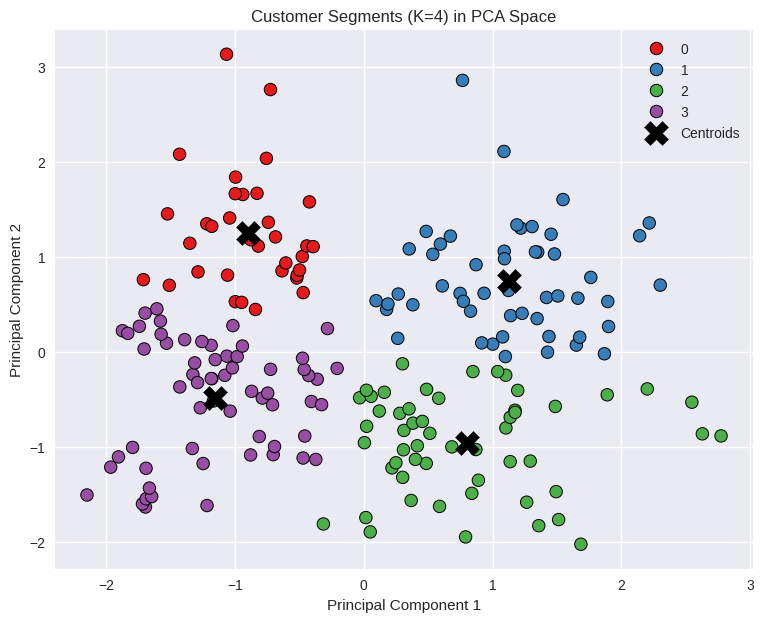


Final Silhouette Score for K=4: 0.4164


In [14]:
# Step 6: Final K-Means Model

# 6.1 - Set your optimal K here
optimal_k = best_k

print("Using Optimal K =", optimal_k)

# 6.2 - Fit final K-Means model on PCA-reduced data
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

# 6.3 - Add cluster labels back to original dataframe
df['Cluster'] = cluster_labels

print(df.head())
print("\nCluster counts:")
print(df['Cluster'].value_counts())

# 6.4 - Visualize final clusters in PCA space
plt.figure(figsize=(9,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels,
                 palette='Set1', s=80, edgecolor='k')

# Plot centroids
centroids = kmeans_final.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], c='black', s=300,
            marker='X', label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Customer Segments (K={optimal_k}) in PCA Space')
plt.legend()
plt.grid(True)
plt.show()

# 6.5 - Final Silhouette Score check
final_score = silhouette_score(X_pca, cluster_labels)
print(f"\nFinal Silhouette Score for K={optimal_k}: {final_score:.4f}")

Cluster Centroids (Original Scale):
           Age  Annual Income (k$)  Spending Score (1-100)  Gender_Encoded
Cluster                                                                   
0        28.44               85.91                   69.41            0.73
1        48.57               75.46                   32.25            0.81
2        47.90               41.33                   33.50            0.24
3        28.51               50.99                   69.29            0.15

Cluster Summary (Actual Customer Averages):
           Age  Annual Income (k$)  Spending Score (1-100)  Count  Female %
Cluster                                                                    
0        29.91               81.50                   73.88     34     17.65
1        47.65               74.63                   30.86     51     17.65
2        49.22               46.22                   34.00     54     87.04
3        27.30               49.82                   67.51     61     81.97


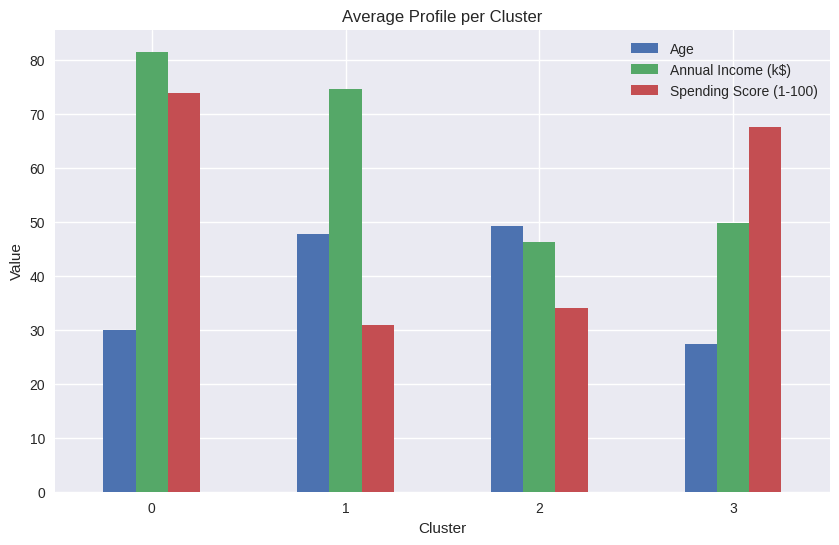

In [16]:
# Step 7: Reverse-Engineering Centroids

# 6.1 - Method 1: Inverse transform PCA centroids back to scaled feature space,
# then inverse transform StandardScaler to get original scale values

centroids_pca = kmeans_final.cluster_centers_          # centroids in PCA space
centroids_scaled = pca.inverse_transform(centroids_pca) # back to scaled feature space
centroids_original = scaler.inverse_transform(centroids_scaled)  # back to original scale

centroids_df = pd.DataFrame(centroids_original, columns=features)
centroids_df.index.name = 'Cluster'
print("Cluster Centroids (Original Scale):")
print(centroids_df.round(2))

# 6.2 - Method 2 (more reliable/practical): Groupby actual customer data per cluster
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary['Count'] = df['Cluster'].value_counts()
cluster_summary['Female %'] = df.groupby('Cluster')['Gender'].apply(lambda x: (x=='Female').mean()*100)

print("\nCluster Summary (Actual Customer Averages):")
print(cluster_summary.round(2))

# 6.3 - Visualize average profile per cluster
cluster_summary[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].plot(
    kind='bar', figsize=(10,6))
plt.title('Average Profile per Cluster')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.show()

           Age  Annual Income (k$)  Spending Score (1-100)  Count  Female %
Cluster                                                                    
0        29.91               81.50                   73.88     34     17.65
1        47.65               74.63                   30.86     51     17.65
2        49.22               46.22                   34.00     54     87.04
3        27.30               49.82                   67.51     61     81.97

=== FINAL PERSONA REPORT ===
               Age  Annual Income (k$)  Spending Score (1-100)  Count  \
Cluster                                                                 
0        29.911765           81.500000               73.882353     34   
1        47.647059           74.627451               30.862745     51   
2        49.222222           46.222222               34.000000     54   
3        27.295082           49.819672               67.508197     61   

          Female %                        Name                 Description 

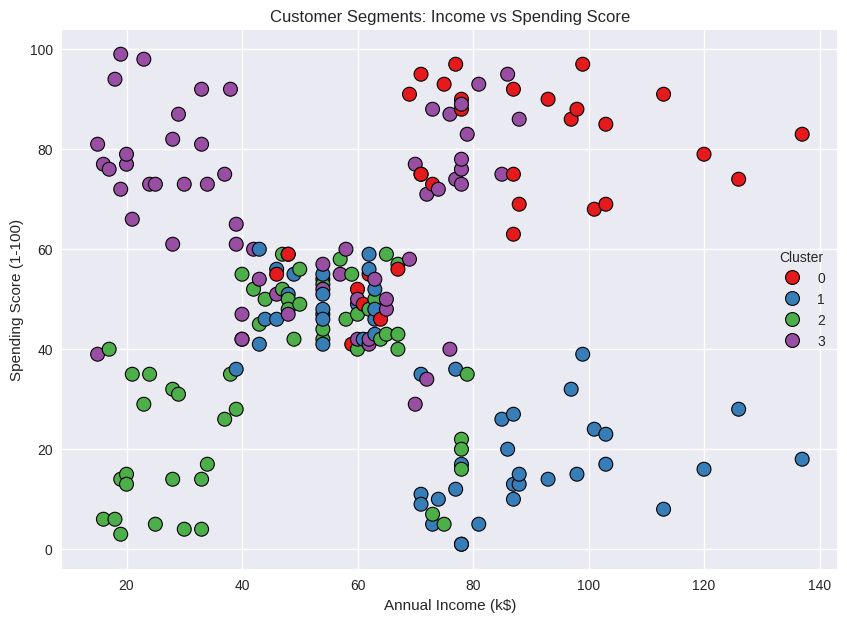


Files saved: customer_segments_final.csv, persona_report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Step 8: Business Personas

# 8.1 - Dekho apna cluster_summary phir se (Step 7 se)
print(cluster_summary.round(2))

# 8.2 - Har cluster ke liye persona naam aur action define karo
# NOTE: Ye aapko cluster_summary ki values dekh kar khud decide karna hai!
# Neeche sirf EXAMPLE hai (Mall_Customers dataset ke common 5-cluster result jaisa)

persona_map = {
    0: {'Name': 'Affluent Conservatives',
        'Description': 'High income, low spending',
        'Action': 'High-touch support, warranties, loyalty programs'},
    1: {'Name': 'High-Value Trendsetters',
        'Description': 'High income, high spending',
        'Action': 'Exclusive perks, early access, experiential marketing'},
    2: {'Name': 'Budget-Conscious Explorers',
        'Description': 'Low income, high spending',
        'Action': 'Influencer campaigns, flash sales, buy-now-pay-later'},
    3: {'Name': 'Conservative Minimizers',
        'Description': 'Low income, low spending',
        'Action': 'Minimize spend, clear price-value, basic utility'},
    4: {'Name': 'Balanced Moderates',
        'Description': 'Average income, average spending',
        'Action': 'Standard offers, seasonal promotions'},
}

# 8.3 - Persona table banao
persona_df = pd.DataFrame(persona_map).T
persona_df.index.name = 'Cluster'
final_report = cluster_summary.join(persona_df)

print("\n=== FINAL PERSONA REPORT ===")
print(final_report)

# 8.4 - Final visualization: Income vs Spending Score colored by Persona
plt.figure(figsize=(10,7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                 hue='Cluster', data=df, palette='Set1', s=100, edgecolor='k')
plt.title('Customer Segments: Income vs Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 8.5 - Save final results to CSV
df.to_csv('customer_segments_final.csv', index=False)
final_report.to_csv('persona_report.csv')

print("\nFiles saved: customer_segments_final.csv, persona_report.csv")

from google.colab import files
files.download('customer_segments_final.csv')
files.download('persona_report.csv')